In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance_matrix
from sklearn.manifold import MDS
import torch
from torch.utils.data import DataLoader

In [3]:
from mapcharting.dataset.dataset import CSIPairsDataset
from mapcharting.dissimilarity.dissimilarity import adp_dissimilarity, timestamp_dissimilarity, geodesic_dissimilarity
from mapcharting.loss.loss import siamese_loss
from mapcharting.model.model import ChannelCharter

In [4]:
csi = np.load("data/csi.npz")["arr_0"]
timestamps = np.load("data/timestamps.npz")["arr_0"]
positions = np.load("data/positions.npz")["arr_0"]

In [ ]:
device = "cuda"
load_cache = True
file = ".cache/adp_dissimilarity.npz"

if not load_cache:
    adp_dissimilarity_matrix = adp_dissimilarity(csi, device=device)
else:
    adp_dissimilarity_matrix = torch.from_numpy(np.load(file), device=device)

In [ ]:
# Cache Matrix
if not load_cache:
    np.savez(".cache/adp_dissimilarity.npz", adp_dissimilarity_matrix.numpy())

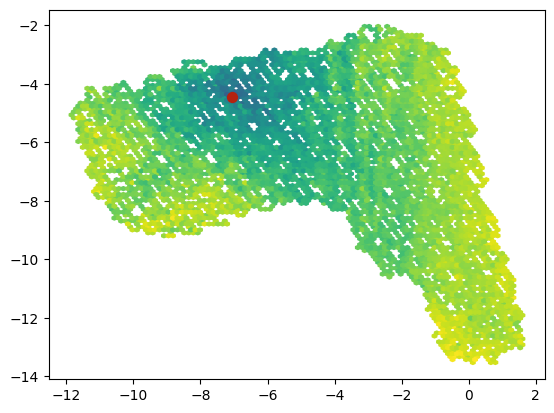

In [7]:
POS = 0

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=adp_dissimilarity_matrix[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [ ]:
if not load_cache:
    timestamp_dissimilarity_matrix = np.abs(np.subtract.outer(timestamps, timestamps))
else:
    timestamp_dissimilarity_matrix = np.load(".cache/timestamp_dissimilarity.npz")

NameError: name 'load_cache' is not defined

In [ ]:
# Cache Matrix
if not load_cache:
    np.savez(".cache/timestamp_dissimilarity.npz", timestamp_dissimilarity_matrix)

/tmp/ipykernel_2724113/548005679.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)


Text(0, 0.5, 'Number of Occurences')

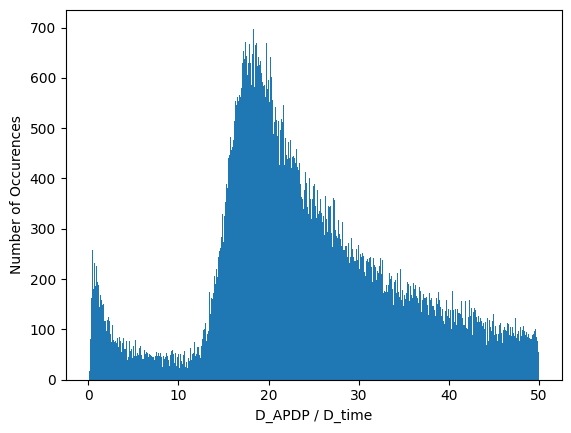

In [24]:
TIME_THRESHOLD = 2
small_time_dissimilarity_indices = np.logical_and(timestamp_dissimilarity_matrix < TIME_THRESHOLD, timestamp_dissimilarity_matrix > 0)
small_time_dissimilarities = timestamp_dissimilarity_matrix[small_time_dissimilarity_indices]
small_adp_dissimilarities = adp_dissimilarity_matrix[small_time_dissimilarity_indices]

n_bins = 1500

fig, ax1 = plt.subplots()
occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)
ax1.set_xlabel("D_APDP / D_time")
ax1.set_ylabel("Number of Occurences")

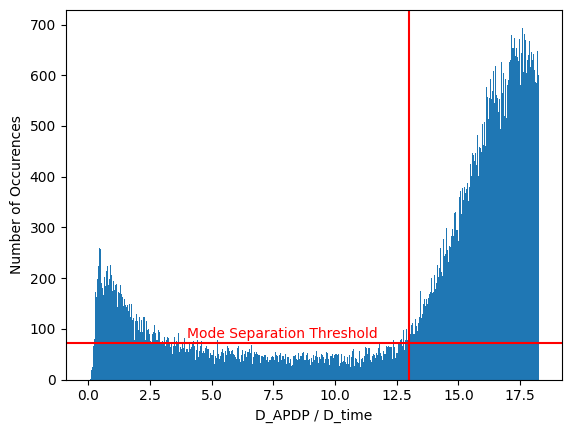

gamma =  12.983333110809326


In [25]:
bin_centers = edges[:-1] + np.diff(edges) / 2.
max_bin = np.argmax(occurences)
min_threshold = np.quantile(occurences[:max_bin], 0.5)

for threshold_bin in range(max_bin - 1, -1, -1):
	if occurences[threshold_bin] < min_threshold:
		break

scaling_factor = bin_centers[threshold_bin]

plt.bar(bin_centers[:max_bin], occurences[:max_bin], width = edges[1] - edges[0])
plt.axhline(y = min_threshold, color = 'r', linestyle = '-')
plt.text(4, min_threshold + 10, "Mode Separation Threshold", color = 'r',)
plt.axvline(x = scaling_factor, color = 'r', linestyle = '-')
plt.xlabel("D_APDP / D_time")
plt.ylabel("Number of Occurences")
plt.show()

print("gamma = ", scaling_factor)

In [ ]:
dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)

SyntaxError: invalid syntax (4194338850.py, line 3)

In [ ]:
if not load_cache:
    dissimilarity_matrix_geodesic = geodesic_dissimilarity(dissimilarity_matrix=dissimilarity_matrix_fused)
else:
    dissimilarity_matrix_geodesic = np.load(".cache/geodesic_dissimilarity.npz")

100%|██████████| 20997/20997 [00:37<00:00, 565.83it/s] 


In [ ]:
if load_cache:
    np.savez(".cache/geodesic_dissimilarity.npz", dissimilarity_matrix_geodesic)

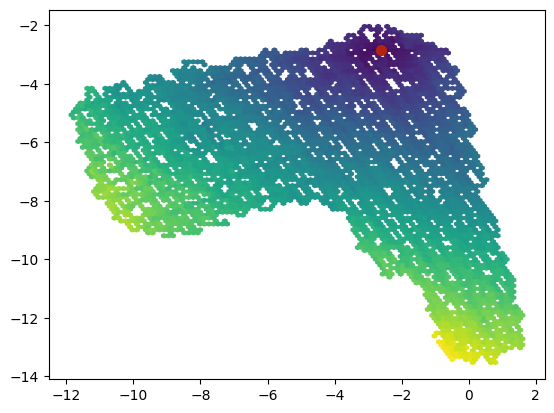

In [28]:
POS = 4165

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=dissimilarity_matrix_geodesic[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [29]:
groundtruth_distance_matrix = distance_matrix(positions, positions)

(20997, 20997)

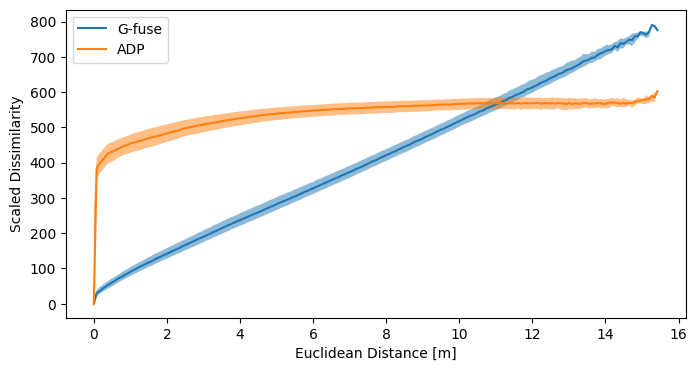

In [30]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None):
	nth_reduction = 10
	dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
	distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
	
	max_distance = np.max(distances_flat)
	bins = np.linspace(0, max_distance, 200)
	bin_indices = np.digitize(distances_flat, bins)
	
	bin_medians = np.zeros(len(bins) - 1)
	bin_25_perc = np.zeros(len(bins) - 1)
	bin_75_perc = np.zeros(len(bins) - 1)
	for i in range(1, len(bins)):
		bin_values = dissimilarities_flat[bin_indices == i]
		if len(bin_values) == 0:                                                                                                                                                                        
			bin_25_perc[i - 1] = bin_medians[i - 1] = bin_75_perc[i - 1] = np.nan                                                                                                                       
			continue                                                                                                                                                                                    
		bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75]) 
	
	plt.plot(bins[:-1], bin_medians, label = label)
	plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, alpha=0.5)
		
plt.figure(figsize=(8,4))

plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-fuse")
plot_dissimilarity_over_euclidean_distance(scaling_factor * adp_dissimilarity_matrix, groundtruth_distance_matrix, "ADP")

plt.legend()
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("Scaled Dissimilarity")
plt.show()

In [31]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    def NormalizeData(in_data):
        return (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions[:,0:2] - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

## MDS Solution

/cluster/raid/home/lizy/projects/mapcharting/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


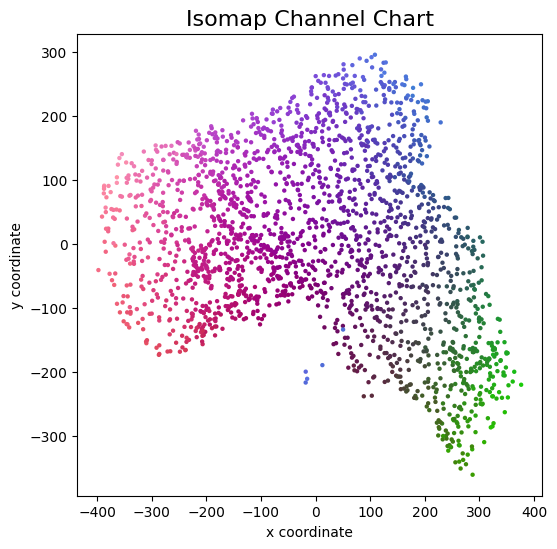

In [35]:
nth_reduction = 10

reduced_dissimilarity_matrix_geodesic = dissimilarity_matrix_geodesic[::nth_reduction, ::nth_reduction]
embedding_isomap = MDS(metric_mds = True, metric = 'precomputed', max_iter = 80, normalized_stress = False, n_init=4)
proj_isomap = embedding_isomap.fit_transform(reduced_dissimilarity_matrix_geodesic)
plot_colorized(proj_isomap, positions[::nth_reduction], title = "Isomap Channel Chart")

## Deep-Learning based

In [36]:
batch_size = 128
csi_dataset = CSIPairsDataset(csi, dissimilarity_matrix_geodesic)
train_loader = DataLoader(csi_dataset, batch_size=batch_size)

In [42]:
learning_rate = 1e-4
epochs = 100

model = ChannelCharter()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
dissimilarity_margin = np.quantile(dissimilarity_matrix_geodesic, 0.01) # 1% of the values

In [43]:
model.train()
for i in range(epochs):
    running_loss = 0
    for csi_a, csi_b, dissimilarity in train_loader:
        optimizer.zero_grad()

        oa = model(csi_a) # (batch, 4)
        ob = model(csi_b) # (batch, 4)

        y_pred = torch.cat([oa, ob], dim=1) # (batch, 4)

        loss = siamese_loss(dissimilarity, y_pred, dissimilarity_margin)
        loss.backward()

        running_loss += loss.item()

        optimizer.step()

    if i % 5 == 0:
        print(f"Epoch: {i} - Loss: {running_loss}")



Epoch: 0 - Loss: 40633.85525512695
Epoch: 5 - Loss: 38162.10388183594
Epoch: 10 - Loss: 34925.14897155762
Epoch: 15 - Loss: 32249.539543151855
Epoch: 20 - Loss: 28643.29768371582
Epoch: 25 - Loss: 25360.537826538086
Epoch: 30 - Loss: 22295.883010864258


KeyboardInterrupt: 

In [45]:
model.save()

In [46]:
m2 = ChannelCharter()
m2.load()

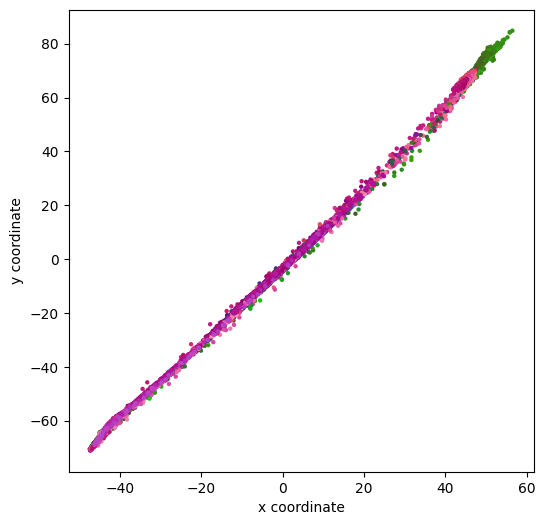

In [47]:
csi_t = torch.from_numpy(csi)

with torch.no_grad():
    m2.eval()
    channel_pos = m2(csi_t)
    plot_colorized(channel_pos, positions)